In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_train, y_train, X_test, y_test = joblib.load("../data/processed_data.pkl")

# Use XGBoost for SHAP (best native support)
from xgboost import XGBClassifier
xgb_model = joblib.load("../models/xgboost.pkl")

print("Loaded model and data")

c:\Users\rohit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model and data


In [2]:
# TreeExplainer is fast and exact for tree-based models
explainer = shap.TreeExplainer(xgb_model)

# Use a sample of test set (SHAP is compute-intensive on full set)
X_sample = X_test.sample(n=2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2000, 38)


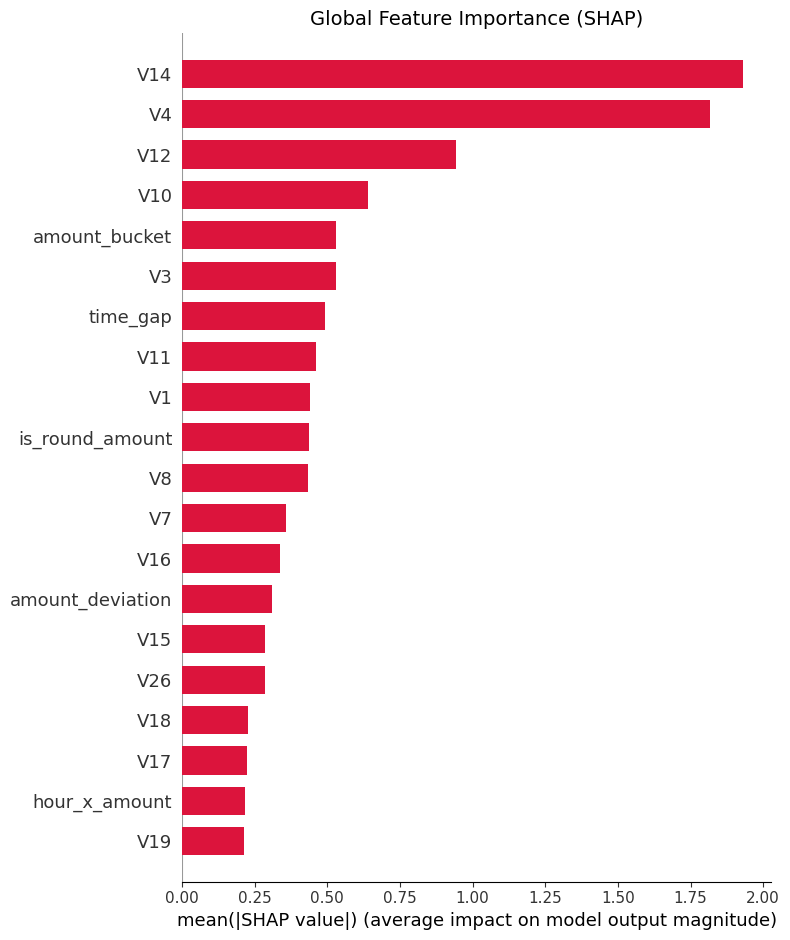

In [3]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False,
                  max_display=20, color="crimson")
plt.title("Global Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("../models/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

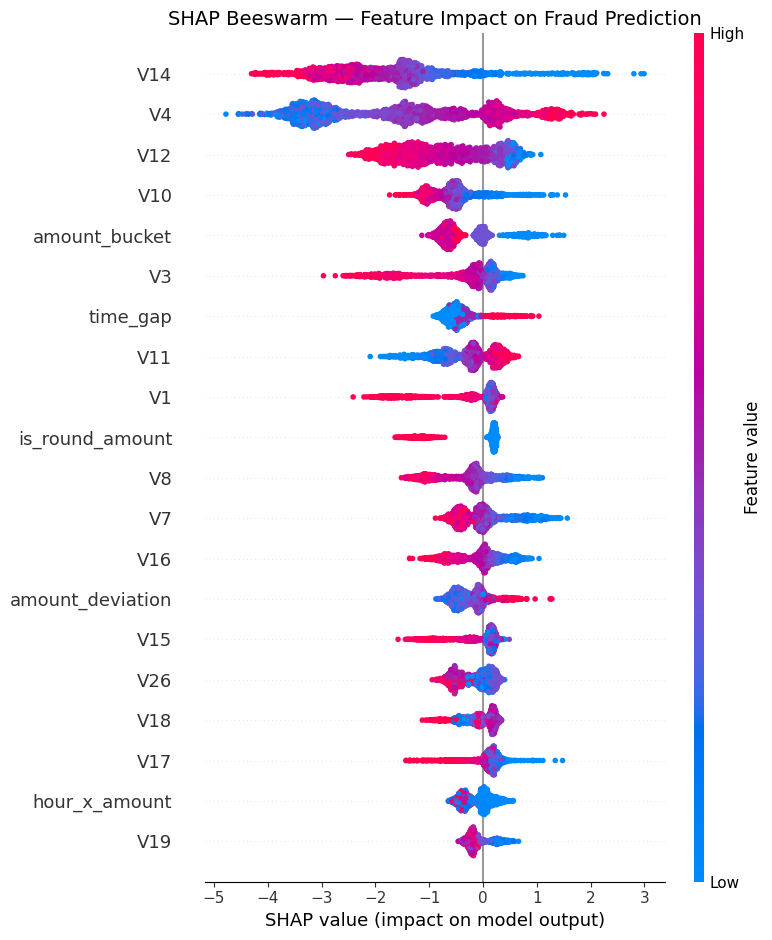

In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
plt.title("SHAP Beeswarm — Feature Impact on Fraud Prediction", fontsize=14)
plt.tight_layout()
plt.savefig("../models/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

=== TRANSACTION EXPLANATION ===
True label: FRAUD
Model probability: 0.9999



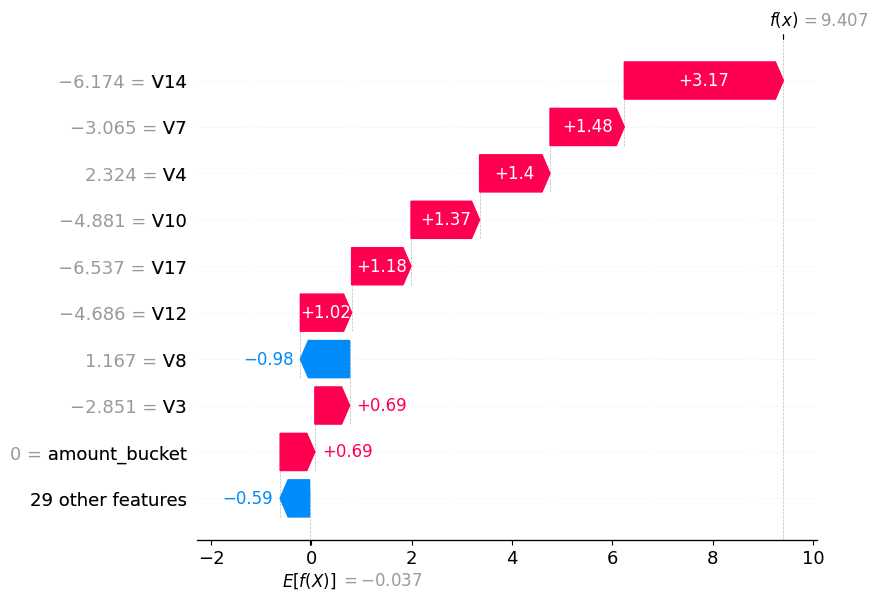

In [5]:
# Pick a confirmed fraud transaction from test set
fraud_indices = y_test[y_test == 1].index
sample_fraud = X_test.loc[fraud_indices[0]:fraud_indices[0]]

shap_single = explainer.shap_values(sample_fraud)

print("=== TRANSACTION EXPLANATION ===")
print(f"True label: FRAUD")
print(f"Model probability: {xgb_model.predict_proba(sample_fraud)[0][1]:.4f}")
print()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_single[0],
        base_values=explainer.expected_value,
        data=sample_fraud.values[0],
        feature_names=sample_fraud.columns.tolist()
    ),
    show=True
)

In [6]:
def explain_transaction(model, explainer, transaction_row, feature_names):
    """
    Generates a plain-English explanation for why a transaction was flagged.
    """
    prob = model.predict_proba(transaction_row)[0][1]
    shap_vals = explainer.shap_values(transaction_row)[0]

    # Get top 3 contributing features
    shap_df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_vals,
        "feature_value": transaction_row.values[0]
    }).sort_values("shap_value", key=abs, ascending=False).head(3)

    lines = [f"⚠️  FRAUD ALERT — Confidence: {prob*100:.1f}%", ""]
    lines.append("Top reasons this transaction was flagged:")

    for _, row in shap_df.iterrows():
        direction = "increases" if row["shap_value"] > 0 else "decreases"
        lines.append(
            f"  • '{row['feature']}' = {row['feature_value']:.2f} "
            f"({direction} fraud risk, SHAP={row['shap_value']:.3f})"
        )

    lines.append("")
    lines.append("Recommendation: Flag for manual review.")
    return "\n".join(lines)


# Test it
explanation = explain_transaction(xgb_model, explainer, sample_fraud,
                                  sample_fraud.columns.tolist())
print(explanation)

⚠️  FRAUD ALERT — Confidence: 100.0%

Top reasons this transaction was flagged:
  • 'V14' = -6.17 (increases fraud risk, SHAP=3.171)
  • 'V7' = -3.07 (increases fraud risk, SHAP=1.481)
  • 'V4' = 2.32 (increases fraud risk, SHAP=1.404)

Recommendation: Flag for manual review.
